# Chapter 4: Spark
## Lab assignment: Exercises with MapReduce on Apache Spark


## Set-up

The first thing we need to do to start working with Spark is to initialize the `SparkContext`. We will also import a few libraries we will use.

In [1]:
from pyspark import SparkConf, SparkContext
conf = SparkConf().setMaster("local[*]").setAppName("Spark Lab")
sc = SparkContext(conf = conf)

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Helper function to test the correctness of the solutions
def test(var, val, msg=""):
    print("1 test passed.") if var == val else print("1 test failed. " + msg)

# Useful tips for programming exercises

When programming in Spark with Jupyter Notebooks it is useful to make use of its interactivity. That is, instead of addressing the exercise as a whole, try to divide it into smaller pieces and program it incrementally, checking that every step is being performed as expected.

To illustrate this, we are going to implement the Word Count program step by step, and you will later be asked to put everything together as part of Exercise 0.

We already know that to count words we need to first divide each sentence (string) of the RDD into words. But before that, we should read the data from a file. We can implement a simple function that takes the filename (and its path) as input, and creates an RDD with it. To check that this works, we could use a `take` action right after loading the file and see the first 10 lines of the file. Let's do this.

> **Important note**: make sure you have downloaded the book in this virtual machine, and use the right path! we have it under the 'data' directory, but you may not.

In [4]:
# First step, check the reading
def word_count(file_path):
    lines = sc.textFile(file_path)

    output = lines.take(10) # trigger the reading of the file
    return output

# Test the function with quixote.txt file
word_count("data/quixote.txt")

['',
 'The Project Gutenberg EBook of The History of Don Quixote by Miguel de Cervantes',
 '',
 'This eBook is for the use of anyone anywhere at no cost and with',
 'almost no restrictions whatsoever.  You may copy it, give it away or',
 're-use it under the terms of the Project Gutenberg License included',
 'with this eBook or online at www.gutenberg.org',
 '',
 '',
 'Title: The History of Don Quixote']

Doing this allows us to see the first 10 elements from the RDD, so we can understand that each element is a string containing a line of the book.

The next step is to divide those lines into words using the `split` function for Strings from Python.

In [5]:
# Next, we check the split
def word_count(file_path):
    lines = sc.textFile(file_path)
    words = lines.map(lambda line: line.split(' '))

    output = words.take(10)
    return output

# Test the function with quixote.txt file
word_count("data/quixote.txt")

[[''],
 ['The',
  'Project',
  'Gutenberg',
  'EBook',
  'of',
  'The',
  'History',
  'of',
  'Don',
  'Quixote',
  'by',
  'Miguel',
  'de',
  'Cervantes'],
 [''],
 ['This',
  'eBook',
  'is',
  'for',
  'the',
  'use',
  'of',
  'anyone',
  'anywhere',
  'at',
  'no',
  'cost',
  'and',
  'with'],
 ['almost',
  'no',
  'restrictions',
  'whatsoever.',
  '',
  'You',
  'may',
  'copy',
  'it,',
  'give',
  'it',
  'away',
  'or'],
 ['re-use',
  'it',
  'under',
  'the',
  'terms',
  'of',
  'the',
  'Project',
  'Gutenberg',
  'License',
  'included'],
 ['with', 'this', 'eBook', 'or', 'online', 'at', 'www.gutenberg.org'],
 [''],
 [''],
 ['Title:', 'The', 'History', 'of', 'Don', 'Quixote']]

Well, in this case, we get a new RDD composed of lists. Is this what we need? Not really, we want an RDD of words. So looking at that output we can see that we should change something. You may recall that `split` returns a list of words that is split by the character given as argument. Hence, if we just want the words in the RDD we must use `flatMap` instead of `map`.

In [6]:
# Next, we check the split
def word_count(file_path):
    lines = sc.textFile(file_path)
    words = lines.flatMap(lambda line: line.split(' '))

    output = words.take(10)
    return output

# Test the function with quixote.txt file
word_count("data/quixote.txt")

['',
 'The',
 'Project',
 'Gutenberg',
 'EBook',
 'of',
 'The',
 'History',
 'of',
 'Don']

Brilliant! Much better now. What is left to finish this? We will ask you to think about it in the next section.

In summary, all exercises can usually be implemented incrementally, which eases finding bugs and problems. If we tried to program the whole Word Count and tested it at the end, we might get an error and could spend much more time trying to correct it and looking to understand where the error comes from. We suggest you test each step of the way to ensure that you are getting what you expect.

# Part I - Basic exercises

## Exercise 0: Word Count with Spark

Let's now implement the complete Word Count program in Spark, considering a few additional things we may need when working with real data. Thus, you're asked to implement a `word_count(file_path)` function that counts the number of words in a document or a number of text documents provided in the input path. The function `word_count(file_path)` should give as an output the 10 most repeated words in descending order of repetitions.

**Input:** Text Document or documents

**Output:** (word, count) - only the 10 words with the highest frequency!

Recommended steps:
1. Read the file or files. Each line should be an element of the RDD. (*transformation*)
2. Split the lines into words. (*transformation*)
3. Filter empty words ('') resulting from previous steps. (*transformation*)
4. Count the number of occurrences of each word. (*transformation*)
5. Return to the driver program the 10 most repeated words. (*action*)

In [6]:
def word_count(file_path):
    # <FILL-IN WITH YOUR CODE>
    lines = sc.textFile(file_path)
    words = lines.flatMap(lambda line: line.split(' '))\
            .filter(lambda word: word != '')\
            .map(lambda word: (word, 1))\
            .reduceByKey(lambda a, b: a + b)\
            .takeOrdered(10, key=lambda x: -x[1])

    return words

# Test the function with quixote.txt file
word_count("data/quixote.txt")

[('the', 20923),
 ('and', 16606),
 ('to', 13492),
 ('of', 12866),
 ('that', 7164),
 ('a', 7003),
 ('in', 6860),
 ('I', 5756),
 ('he', 5640),
 ('for', 4534)]

The program should pass the following test:

In [7]:
top10_quixote = word_count("data/quixote.txt")
print(top10_quixote)
test(top10_quixote, [('the', 20923), ('and', 16606), ('to', 13492), ('of', 12866),
                                  ('that', 7164), ('a', 7003), ('in', 6860), ('I', 5756), ('he', 5640),
                                  ('for', 4534)], "Try again!")

[('the', 20923), ('and', 16606), ('to', 13492), ('of', 12866), ('that', 7164), ('a', 7003), ('in', 6860), ('I', 5756), ('he', 5640), ('for', 4534)]
1 test passed.


### Improving Word Count (I): removing punctuation symbols

It seems like the previous Word Count function is working properly, but there are still many things we can do to improve it. Let's start by removing punctuation symbols. When they are attached to the words, we are counting them as different words (e.g., 'hello,' is different from 'hello').

Use the `remove_punctuation_symbols(text)` function to count all words the same regardless of capitalization, punctuation marks, etc.

Steps to follow:
1. Read the file. Each line is an element of the RDD.
2. Remove punctuation marks. (***New***)
2. Divide the lines into words.
3. Filter out empty words.
4. Count occurrences of each word.
5. Return the 10 most repeated words to the driver.

In [8]:
import re
def remove_punctuation_symbols(text):
    """This function converts the string to lower case and removes punctuation symbols and extra spaces"""
    accepted_chars = re.compile(r'[^0-9a-zA-Z ]')
    text = accepted_chars.sub(' ', text.lower()).strip()
    return re.sub(' +', ' ', text)

The above function removes punctuation symbols and each letter is converted lower case. Let's test a couple of examples:

In [9]:
remove_punctuation_symbols('Hi! How are you?')

'hi how are you'

In [10]:
remove_punctuation_symbols(' Removing_all*kind^of+punctuations and extra       spaces     ')

'removing all kind of punctuations and extra spaces'

In [11]:
def word_count(filePath):
    # <FILL-IN WITH YOUR CODE>
    lines = sc.textFile(filePath)
    
    words = lines.map(lambda word: remove_punctuation_symbols(word))\
            .flatMap(lambda line: line.split(' '))\
            .filter(lambda word: word != '')\
            .map(lambda word: (word, 1))\
            .reduceByKey(lambda a, b: a + b)\
            .takeOrdered(10, key=lambda x: -x[1])
    
    return words

word_count("data/quixote.txt")

[('the', 22471),
 ('and', 17722),
 ('to', 14006),
 ('of', 13491),
 ('that', 7993),
 ('in', 7335),
 ('a', 7287),
 ('i', 6653),
 ('he', 6157),
 ('it', 5680)]

In [12]:
top10_quixote = word_count("data/quixote.txt")
test(top10_quixote, [('the', 22471), ('and', 17722), ('to', 14006), ('of', 13491), ('that', 7993),
                                 ('in', 7335), ('a', 7287), ('i', 6653), ('he', 6157), ('it', 5680)],
                  'Try again!')

1 test passed.


### Improving word count II: removing stop words

We are now better at counting words after removing the punctuation symbols, but we can see that the most repeated words are meaningless, in the sense that they are just words that do not provide any useful information about the text itself. In fact, these are known as [stop words](https://en.wikipedia.org/wiki/Stop_word).

Here is a list of common English stop words:

In [13]:
stop_words = ['ourselves', 'hers', 'between', 'yourself', 'but', 'again', 'there',
              'about', 'once', 'during', 'out', 'very', 'having', 'with', 'they',
              'own', 'an', 'be', 'some', 'for', 'do', 'its', 'yours', 'such', 'into',
              'of', 'most', 'itself', 'other', 'off', 'is', 's', 'am', 'or', 'who',
              'as', 'from', 'him', 'each', 'the', 'themselves', 'until', 'below',
              'are', 'we', 'these', 'your', 'his', 'through', 'don', 'nor', 'me',
              'were', 'her', 'more', 'himself', 'this', 'down', 'should', 'our',
              'their', 'while', 'above', 'both', 'up', 'to', 'ours', 'had', 'she',
              'all', 'no', 'when', 'at', 'any', 'before', 'them', 'same', 'and',
              'been', 'have', 'in', 'will', 'on', 'does', 'yourselves', 'then',
              'that', 'because', 'what', 'over', 'why', 'so', 'can', 'did', 'not',
              'now', 'under', 'he', 'you', 'herself', 'has', 'just', 'where', 'too',
              'only', 'myself', 'which', 'those', 'i', 'after', 'few', 'whom', 't',
              'being', 'if', 'theirs', 'my', 'against', 'a', 'by', 'doing', 'it',
              'how', 'further', 'was', 'here', 'than']

Use this list to remove this words from our RDD to avoid counting them.

In [14]:
def word_count(filePath):
    # <FILL-IN WITH YOUR CODE>
    lines = sc.textFile(filePath)
    # Convert to set for O(1) lookups
    stop_words_set = set(stop_words)
    
    words = lines.map(lambda word: remove_punctuation_symbols(word))\
            .flatMap(lambda line: line.split(' '))\
            .filter(lambda word: word != '' and word not in stop_words_set)\
            .map(lambda word: (word, 1))\
            .reduceByKey(lambda a, b: a + b)\
            .takeOrdered(10, key=lambda x: -x[1])
    
    return words

word_count("data/quixote.txt")

[('said', 2627),
 ('quixote', 2327),
 ('sancho', 2205),
 ('one', 1623),
 ('would', 1251),
 ('thou', 1229),
 ('say', 904),
 ('good', 889),
 ('may', 855),
 ('see', 774)]

In [15]:
top10_quixote = word_count("data/quixote.txt")
test(top10_quixote, [('said', 2627), ('quixote', 2327), ('sancho', 2205), ('one', 1623), ('would', 1251),
                                  ('thou', 1229), ('say', 904), ('good', 889), ('may', 855), ('see', 774)],
                  'Try again!')

1 test passed.


You will notice that there are still several words that are typically found in books (like said, say,...). You can still add new unwanted words to the list of stop words to get more meaningful words only. This is an example of how we can incrementally improve our initial solution. In reality, whether removing words is required or not would be just a requisite defined by the specific application you are working on.

## Exercise 1. Histogram of word repetition

Provide a histogram of word repetitions, that is, the number of words that are repeated X times:

* 1 time - 3 words
* 2 times - 10 words
* 3 times, 20 words
...

You are asked to implement a `histogram_reps(file_path)` function in Spark that **must not** use the function `word_count(file_path)`, but it could use part of the code you did before. All the processing must be done with RDDs, and there should be a single `collect()` at the end to return a list. The list must be ordered by the number of times. Recall removing punctuation symbols when computing the histogram (but don't remove stop words).

**Input**: A text document or multiple text documents

**Output**: (X times, number of words)


In [16]:
def histogram_reps(file_path):
    # <FILL-IN WITH YOUR CODE>
    lines = sc.textFile(file_path)
    
    histogram = lines.map(lambda line: remove_punctuation_symbols(line))\
                     .flatMap(lambda line: line.split(' '))\
                     .filter(lambda word: word != '')\
                     .map(lambda word: (word, 1))\
                     .reduceByKey(lambda a, b: a + b)\
                     .map(lambda x: (x[1], 1))\
                     .reduceByKey(lambda a, b: a + b)\
                     .sortBy(lambda x: x[0])\
                     .collect()
    
    return histogram

histogram_reps('data/quixote.txt')[:20] # look at the first 20 results

[(1, 6303),
 (2, 2469),
 (3, 1382),
 (4, 903),
 (5, 688),
 (6, 511),
 (7, 367),
 (8, 340),
 (9, 239),
 (10, 207),
 (11, 171),
 (12, 199),
 (13, 135),
 (14, 132),
 (15, 118),
 (16, 106),
 (17, 94),
 (18, 100),
 (19, 79),
 (20, 74)]

The program should pass the following test:

In [17]:
hist_quixote = histogram_reps("data/quixote.txt")
test(hist_quixote[:10],[(1, 6303), (2, 2469), (3, 1382), (4, 903), (5, 688), (6, 511), (7, 367), (8, 340),
                                     (9, 239), (10, 207)], "Try again!")

1 test passed.


You could plot this with the matplotlib library:

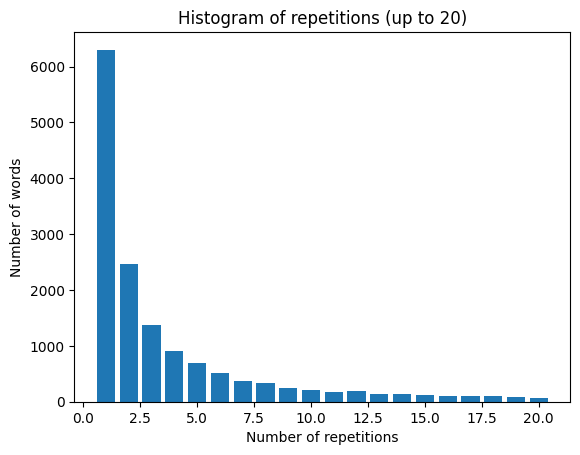

In [18]:
(x_values, y_values) = zip(*hist_quixote[:20])
plt.bar(x_values, y_values)
plt.title('Histogram of repetitions (up to 20)')
plt.xlabel('Number of repetitions')
plt.ylabel('Number of words')
plt.show()

## Exercise 2. Average length of the words in a document

You are now asked to implement an `average_length(file_path)` function in Spark that provides the average length of the words in a document or documents. All the processing must be done with RDDs, and the last instruction must be the only one returning a result to the driver. Recall removing punctuation symbols before computing the average (but don't remove stop words).

**Input**: A text document or multiple text documents

**Output**: Average length of the words

**Note: Again, we are going to assume that the maximum word length is 16 characters, so anything above that shouldn't be used to compute the average**


You can do it in two different ways (you can try both and check possible differences):

- **Option 1**. As we have done in Chapter 2 (MapReduce): you will need to get the total length of the words in the text and the total number of words in just one MapReduce job. Then, you just need to make the division.

In [19]:
def average_length(file_path):
    # <FILL-IN WITH YOUR CODE>
    lines = sc.textFile(file_path)
    
    total_length, total_count = lines\
        .map(lambda line: remove_punctuation_symbols(line))\
        .flatMap(lambda line: line.split(' '))\
        .filter(lambda word: word != '' and len(word) <= 16)\
        .map(lambda word: (len(word), 1))\
        .reduce(lambda a, b: (a[0] + b[0], a[1] + b[1]))
    
    return total_length / total_count

average_length("data/quixote.txt")

4.144714731443846

The program should pass the following test:

In [20]:
avg = average_length("data/quixote.txt")
test(round(avg,5), 4.14471, 'Try again!')

1 test passed.


- **Option 2**. Using some built-in functions from Spark: you can think of a function available from Spark API that can simplify the implementation.

In [21]:
def average_length(file_path):
    # <FILL-IN WITH YOUR CODE>
    lines = sc.textFile(file_path)
    
    return lines \
        .map(lambda line: remove_punctuation_symbols(line)) \
        .flatMap(lambda line: line.split(' ')) \
        .filter(lambda word: word != '' and len(word) <= 16) \
        .map(lambda word: float(len(word))) \
        .mean()

average_length("data/quixote.txt")

4.1447147314438695

The program should pass the following test:

In [22]:
avg = average_length("data/quixote.txt")
test(round(avg,5), 4.14471, 'Try again!')

1 test passed.


## Exercise 3. LastFM list of top 20 most played artists (groups)

You are asked to implement a `top20_artists(file_path)` function in Spark that provides the list of the top 20 most listened artists (groups) in the [LastFM 360K users dataset](http://ocelma.net/MusicRecommendationDataset/lastfm-360K.html).

We will download the dataset using Python and get a subset of it while developing our solution. Then, you will test it with the whole dataset.

The [LastFM dataset we are going to use](http://ocelma.net/MusicRecommendationDataset/index.html) has the following format (separated by tab character `'\t'`):

    user-id \t artist-id \t artist-name \t number_of_plays

That is, we have a row for each `user-id` and `artist-id` with the number of times the user has played a track from that artists/group.

The function should have the following input and output:

**Input:** LastFM file (`usersha1-artmbid-artname-plays.tsv` or a subset of it)

**Output:** List of the 20 most played artist/groups ordered by the number of total plays


We will first prepare the data:
* Download it from http://mtg.upf.edu/static/datasets/last.fm/lastfm-dataset-360K.tar.gz
* Decompress the file
* Get a subset of data for the first tests

We will start installing `wget` if it is not yet installed in our environment. With `wget` we are able to download any file from the internet using Python (also available in the command line of Unix-based systems).

In [23]:
!pip install wget

  Using cached wget-3.2-py3-none-any.whl

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


We can now use `wget` to download the dataset (570mb).

In [24]:
import wget
wget.download('http://mtg.upf.edu/static/datasets/last.fm/lastfm-dataset-360K.tar.gz', out='data')

'data/lastfm-dataset-360K.tar.gz'

Once downloaded, we can decompress the file (if something fails, you can also decompress it yourself from the file explorer).

In [25]:
!tar -xzf data/lastfm-dataset-360K.tar.gz -C data/

We will now generate a subset with the first 3000 lines named `sample3000_usersha1-artmbid-artname-plays.tsv`. This will help us testing our solution faster.

If you are using a UNIX system, you could do this very easily as:

```
!head -n 1000 'data/lastfm-dataset-360K/usersha1-artmbid-artname-plays.tsv' > 'data/lastfm-dataset-360K/sample3000_usersha1-artmbid-artname-plays.tsv'
```

But in case you are not, you can use the following function:

In [26]:
def get_subset(input_filename, output_filename, num_lines, enc = "utf-8"):
    with open(input_filename, encoding=enc) as openfile:
        with open(output_filename, 'w', encoding=enc) as outfile:
            for i in range(num_lines):
                line = openfile.readline()
                outfile.write(line)

In [27]:
get_subset('data/lastfm-dataset-360K/usersha1-artmbid-artname-plays.tsv','data/lastfm-dataset-360K/sample3000_usersha1-artmbid-artname-plays.tsv', 3000 )

You can now start programming the solution.

In [28]:
def top20_artists(file_path):
    # <FILL-IN WITH YOUR CODE>
    lines = sc.textFile(file_path)
    
    return lines \
        .map(lambda line: line.split('\t')) \
        .filter(lambda parts: len(parts) == 4) \
        .map(lambda parts: (parts[2].strip().lower(), int(parts[3].strip()))) \
        .reduceByKey(lambda a, b: a + b) \
        .takeOrdered(20, key=lambda x: -x[1])

top20_artists('./data/lastfm-dataset-360K/sample3000_usersha1-artmbid-artname-plays.tsv')
#top20_artists('./data/lastfm-dataset-360K/usersha1-artmbid-artname-plays.tsv')

[('radiohead', 13117),
 ('the most serene republic', 12763),
 ('nine inch nails', 11686),
 ('arctic monkeys', 10943),
 ('stars', 9045),
 ('the beatles', 8682),
 ('3 na bossa', 7925),
 ('coldplay', 7899),
 ('broken social scene', 6711),
 ('kingston wall', 5992),
 ('bright eyes', 5914),
 ('the libertines', 5727),
 ('have heart', 5361),
 ('boris', 5337),
 ('sigur rós', 5177),
 ('luminous orange', 5120),
 ('blink-182', 4660),
 ('they might be giants', 4558),
 ('queen', 4451),
 ('bob dylan', 4443)]

The program should pass the following tests.

In [29]:
top20_artists_small = top20_artists('./data/lastfm-dataset-360K/sample3000_usersha1-artmbid-artname-plays.tsv')
test(top20_artists_small, [(u'radiohead', 13117), (u'the most serene republic', 12763), (u'nine inch nails', 11686),
                                       (u'arctic monkeys', 10943), (u'stars', 9045), (u'the beatles', 8682), (u'3 na bossa', 7925),
                                       (u'coldplay', 7899), (u'broken social scene', 6711), (u'kingston wall', 5992), (u'bright eyes', 5914),
                                       (u'the libertines', 5727), (u'have heart', 5361), (u'boris', 5337), (u'sigur r\xf3s', 5177),
                                       (u'luminous orange', 5120), (u'blink-182', 4660), (u'they might be giants', 4558), (u'queen', 4451),
                                       (u'bob dylan', 4443)],
                  'Try it again!')

1 test passed.


When running the largest dataset, you can take a look to its progress at <http://localhost:4040> or at the command line. If it takes too long in your PC, running the previous test should be enough.

In [30]:
top20_artists_big = top20_artists('./data/lastfm-dataset-360K/usersha1-artmbid-artname-plays.tsv')
test(top20_artists_big, [(u'the beatles', 30499140), (u'radiohead', 27452136), (u'coldplay', 16701858), (u'pink floyd', 15965959),
                                     (u'metallica', 15498759), (u'muse', 15463089), (u'nine inch nails', 14090643), (u'red hot chili peppers', 13562637),
                                     (u'linkin park', 12848569), (u'system of a down', 11927204), (u'in flames', 11295957),
                                     (u'death cab for cutie', 10587605), (u'placebo', 9848924), (u'nightwish', 9765770), (u'the killers', 9607866),
                                     (u'iron maiden', 9509435), (u'bob dylan', 9454759), (u'nirvana', 9284068), (u'depeche mode', 9243291),
                                     (u'rammstein', 8809758)],
                  'Try it again!')

1 test passed.


## Exercise 4. Find a list of common friends between pairs of friends

You are asked to design the `map` and `reduce` functions to obtain a list of common friends for each pair of friends. That is, for each two people that are friends (assuming friendship is bi-directional), you need to find the friends in common. As input, you receive a file that contains a list of friends for each person. Using `map` and `reduce` functions, you should find for each pair of friends, the list of common friends.

**Input**: A file with the following format: Person -> List of friends. 

```
Isaac -> Mikel John Lucy
Mikel -> Isaac John Lucy Claudia
John -> Isaac Mikel Lucy Claudia
Lucy -> Isaac Mikel John Claudia
Claudia -> Mikel John Lucy
```

**Output**: (pair of friends, list of common friends)
```
(Isaac, Mikel)    -> [John, Lucy]
(Claudia, Mikel)  -> [John, Lucy]
(John, Lucy)      -> [Claudia, Isaac, Mikel]
(Isaac, John)     -> [Lucy, Mikel]
(Isaac, Lucy)     -> [John, Mikel]
(John, Mikel)     -> [Claudia, Isaac, Lucy]
(Lucy, Mikel)     -> [Claudia, Isaac, John]
(Claudia, John)   -> [Lucy, Mikel]
(Claudia, Lucy)   -> [John, Mikel]

```

In [33]:
def common_friends(file_path):
    lines = sc.textFile(file_path)

    # Parse: (person, [friend1, friend2, ...])
    parsed = lines \
        .map(lambda line: line.split(' -> ')) \
        .map(lambda parts: (parts[0].strip(), parts[1].strip().split(' ')))

    # Map: emit (sorted_pair, friends_set) for every friend of each person
    def emit_pairs(person_friends):
        person, friends = person_friends
        friends_set = set(friends)
        pairs = []
        for friend in friends:
            pair = tuple(sorted([person, friend]))
            pairs.append((pair, friends_set))
        return pairs

    result = parsed \
        .flatMap(emit_pairs) \
        .reduceByKey(lambda a, b: a & b) \
        .map(lambda x: (x[0], sorted(list(x[1])))) \
        .sortBy(lambda x: x[0]) \
        .collect()

    return result


import tempfile, os

example_friends = [
    "Isaac -> Mikel John Lucy",
    "Mikel -> Isaac John Lucy Claudia",
    "John -> Isaac Mikel Lucy Claudia",
    "Lucy -> Isaac Mikel John Claudia",
    "Claudia -> Mikel John Lucy",
]

with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
    f.write('\n'.join(example_friends))
    tmp_path = f.name

result = common_friends(tmp_path)
os.unlink(tmp_path)

print("(pair of friends) -> [common friends]")
print("-" * 45)
for pair, common in result:
    print(f"({pair[0]}, {pair[1]}) -> {common}")

(pair of friends) -> [common friends]
---------------------------------------------
(Claudia, John) -> ['Lucy', 'Mikel']
(Claudia, Lucy) -> ['John', 'Mikel']
(Claudia, Mikel) -> ['John', 'Lucy']
(Isaac, John) -> ['Lucy', 'Mikel']
(Isaac, Lucy) -> ['John', 'Mikel']
(Isaac, Mikel) -> ['John', 'Lucy']
(John, Lucy) -> ['Claudia', 'Isaac', 'Mikel']
(John, Mikel) -> ['Claudia', 'Isaac', 'Lucy']
(Lucy, Mikel) -> ['Claudia', 'Isaac', 'John']
